# Исследование ёмкости embedding векторов, когда кол-во фичей = размерности embedding (full basis)

In [1]:
import os, sys

import math
from collections import defaultdict, namedtuple, Counter
import json
import re
import pprint
from enum import Flag, StrEnum, auto # @launchit.collect

from tqdm.notebook import tqdm
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

sys.path.append(os.path.join(project_root_path, 'lib'))
from utils import *
from logging_utils import *

# Setup

In [2]:
LOG = Logging.get()
RNG = np.random.default_rng()
ArrayUtils.init()
xp = ArrayUtils.xp

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/14_embedding',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'self_fname': '/home/misha/dev/mine/neurovision/14_embedding/full_capacity_emb_02.ipynb',
 'self_name': 'full_capacity_emb_02',
 'subproject_name': '14_embedding',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



Возьмём disentangled representation, когда одна фича - один разряд. В этом случае, сколько разрядов, столько и уникальных фичей можно безупречнно закодировать и декодировать в векторе. 3D -> 3 фичи, 300D -> 300 фичей.

Теперь возьмем distributed representation, где фичи - это направления, которые не на 100% орогональны (т.е. имеется некоторая коррелированность). С одной стороны это плохо, с другой - хорошо, т.к. кол-во фичей, которое можно положить в вектор, увеличивается очень сильно (на порядки). Т.е. закодировать можно много информации. Другой вопрос - а что с раскодировкой, сколько можно прочитать информации без её зашумления?

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

# Embedding Size, ES=768

In [3]:
EMBEDDING_SIZE = 768

# Feature Bank Size, FBS

FBS - сколько всего фичей знает система. Банк знаний

# Features Count, FC

FC - сколько фичей (их значений) мы хотим записать в один HDV. Чем больше, тем тяжелее. Если FBS <= EMBEDDING_SIZE, то безошибочно можн сохранить FBS фичей. Если FBS >> EMBEDDING_SIZE, то уже неизбежно будут ошибки, т.к. фичи будут хоть немного, но коррелированы, и сохранение нескольких фичей в один вектор будет приводить к фантомным значениям фичей (которые мы даже и не хотели сохранять).

# ES/FBS/FC=768/768/100, как есть

In [4]:
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = 100

In [5]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE))
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы

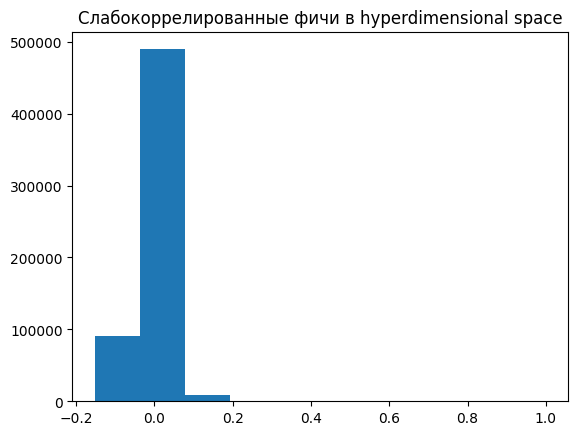

In [6]:
plt.title('Слабокоррелированные фичи в hyperdimensional space')
plt.hist((features @ features.T).ravel());

In [7]:
batch_size = 100
batch = np.zeros((batch_size, EMBEDDING_SIZE)) 

for i in range(len(batch)):
    feature_inds = RNG.choice(len(features), FEATURES_COUNT, replace=False)
    feature_values = np.zeros(len(features))
    feature_values[feature_inds] = RNG.uniform(0, 1, size=FEATURES_COUNT) # here we get a sparsed vectors
    batch[i] = feature_values 

# encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
# mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
embeddings = (features.T @ batch.T).T
# decode -> extract feature values from embedding
# mnemonics: embedding in rows, features in columns
batch_hat = F.relu(torch.tensor(embeddings @ features.T)).numpy()
mse = ((batch - batch_hat) ** 2).mean()
print(f'MSELoss={mse}')

MSELoss=0.024771492451912062


**ВЫВОДЫ**

Несмотря на гиперразмерность (фичи почти ортогональны), мы видим, что фичи кодируются/декодируются с ошибками. 

# ES/FBS/FC=768/768/768, как есть

In [8]:
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = EMBEDDING_SIZE

In [9]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE))
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы

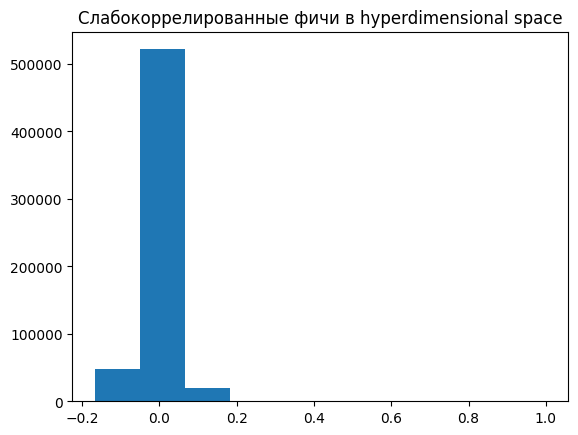

In [10]:
plt.title('Слабокоррелированные фичи в hyperdimensional space')
plt.hist((features @ features.T).ravel());

In [11]:
batch = RNG.uniform(0, 1, size=(100, FEATURES_COUNT)) # each sample contains value for each value
# encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
# mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
embeddings = (features.T @ batch.T).T
# decode -> extract feature values from embedding
# mnemonics: embedding in rows, features in columns
batch_hat = F.relu(torch.tensor(embeddings @ features.T)).numpy()
mse = ((batch - batch_hat) ** 2).mean()
print(f'MSELoss={mse}')

MSELoss=0.22797227722459415


**ВЫВОДЫ**

Несмотря на гиперразмерность (фичи почти ортогональны), мы видим, что фичи кодируются/декодируются с ошибками. По сравнению с предыдущим вариантом ошибка получается заметно выше, что в принципе ожидаемо

# ES/FBS/FC=768/768/768, точное решение

In [12]:
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = EMBEDDING_SIZE

QR refresher

In [13]:
any_vector = RNG.uniform(-1, +1, 3)
any_vector /= np.linalg.norm(any_vector)
start_basis = np.eye(len(any_vector))
start_basis[:,0] = any_vector
Q, R = np.linalg.qr(start_basis) 
start_basis, np.round(Q, 2) # bases are in columns

(array([[ 0.69159525,  0.        ,  0.        ],
        [-0.44183582,  1.        ,  0.        ],
        [ 0.57138176,  0.        ,  1.        ]]),
 array([[-0.69, -0.34, -0.64],
        [ 0.44, -0.9 ,  0.  ],
        [-0.57, -0.28,  0.77]]))

In [14]:
np.linalg.norm(Q, axis=0), np.linalg.norm(Q, axis=1), 

(array([1., 1., 1.]), array([1., 1., 1.]))

In [15]:
np.round(start_basis.T @ start_basis, 4), np.round(Q @ Q.T, 4)

(array([[ 1.    , -0.4418,  0.5714],
        [-0.4418,  1.    ,  0.    ],
        [ 0.5714,  0.    ,  1.    ]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))

QR декомпозиция выдаёт базис, который есть в колонках

In [16]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE))

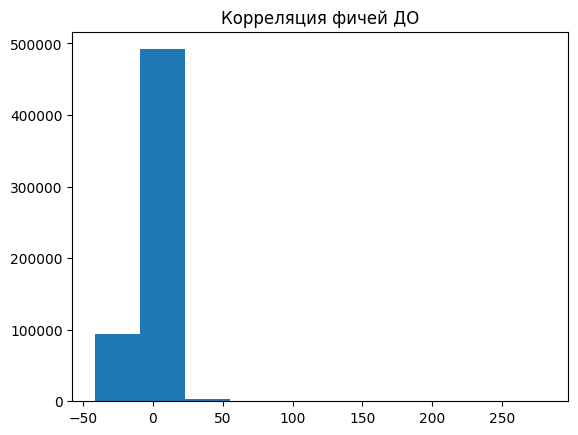

In [17]:
plt.title('Корреляция фичей ДО')
plt.hist((features @ features.T).ravel());

In [18]:
# Получаем из мусора ортогональный базис
features, _ = np.linalg.qr(features)
features = features.T
assert np.all(np.round(features @ features.T, 4) == np.eye(len(features)))

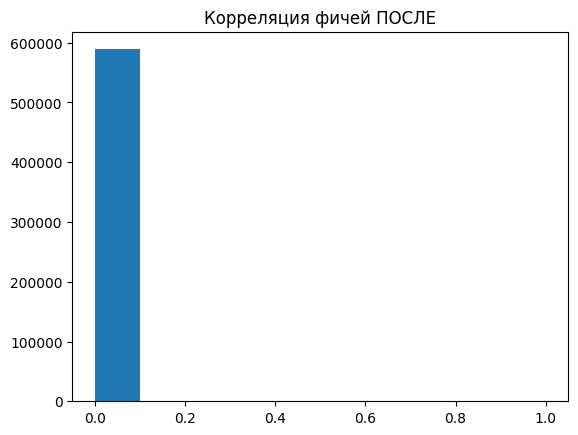

In [19]:
plt.title('Корреляция фичей ПОСЛЕ')
plt.hist((features @ features.T).ravel());

In [20]:
features_count_list = 1 + np.arange(len(features))
diff_metrics = defaultdict(list)

for features_count in tqdm(features_count_list):
    feature_inds = RNG.choice(len(features), features_count, replace=False)
    feature_values = np.zeros(len(features))
    # craft a disentagled representation of features (1 feature = 1 slot)
    feature_values[feature_inds] = RNG.uniform(0, 1, size=(features_count))
    # encode -> make embedding: scale each feature by corresponding value, sum all features (disentagled -> distributed representation)
    embedding = ((features.T * feature_values).T).sum(axis=0) 
    # decode -> extract feature values from embedding
    feature_values_hat = F.relu(torch.tensor(features @ embedding)).numpy()
    # feature_values_hat = (features @ embedding) - bias
    diff = feature_values - feature_values_hat
    abs_diff = np.abs(diff)
    diff_metrics['abs_min'].append(abs_diff.min())
    diff_metrics['abs_max'].append(abs_diff.max())
    diff_metrics['abs_mean'].append(abs_diff.mean())
    diff_metrics['mse_loss'].append((diff ** 2).sum() / len(feature_values))
    diff_metrics['l1_loss'].append(abs_diff.sum() / len(feature_values))

  0%|          | 0/768 [00:00<?, ?it/s]

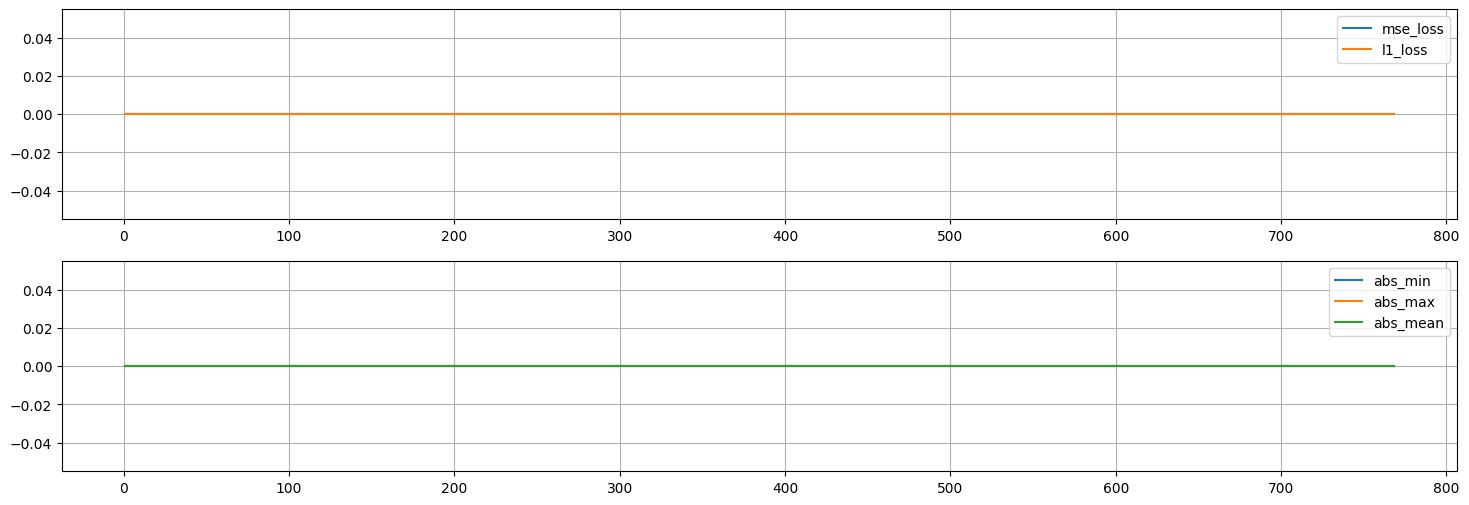

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1)
fig.set_figwidth(18)
fig.set_figheight(6)

for key in ('mse_loss', 'l1_loss'):
    values = diff_metrics[key]
    ax1.plot(features_count_list, np.round(values, 9), label=key)
    ax1.grid(True)
    ax1.legend();

for key in ('abs_min', 'abs_max', 'abs_mean'):
    values = diff_metrics[key]
    ax2.plot(features_count_list, np.round(values, 9), label=key)
    ax2.grid(True)
    ax2.legend();

**ВЫВОДЫ**

Ожидаемый результат, что когда мы имеем ортогональный базис и размер этого базиса равняется размерности пространства, то в вектор можно идеально закодировать и раскодировать кол-во real-valued фич, равное размерности (например, 768)

# ES/FBS/FC=768/768/768, оптимизация

In [22]:
FEATURES_BANK_SIZE = EMBEDDING_SIZE
FEATURES_COUNT = EMBEDDING_SIZE

In [29]:
# Стартуем с мусора и пытаемся получить хороший базис через градиентный спуск
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE)).astype('float32')
features = (features.T / np.linalg.norm(features, axis=1)).T # features axes are in rows
assert np.any(~((features @ features.T) == np.eye(len(features)))) # тут не ожидаем Identity матрицы, т.к. фичи всё же слабо, но коррелированы
features = torch.tensor(features, requires_grad=True, device=CONFIG.cuda_device)

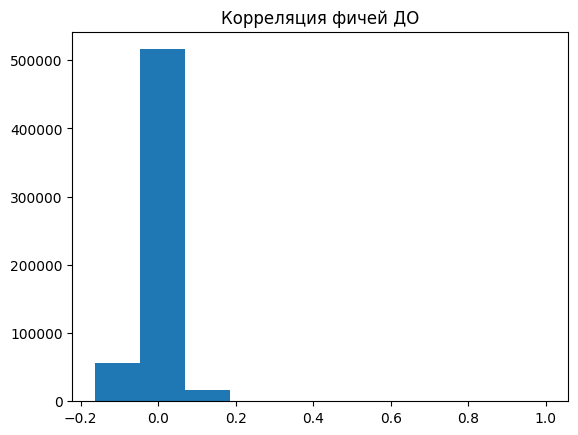

In [30]:
plt.title('Корреляция фичей ДО')
plt.hist((features @ features.T).detach().cpu().numpy().ravel());

In [31]:
# decorrelate feature axes by gradient descent optimization procedure
optimizer = torch.optim.Adam([features], lr=0.0001)
epochs_count = 6000
batch_size = 100

for epoch in tqdm(range(epochs_count + 1)):
    optimizer.zero_grad()
    batch = RNG.uniform(0, 1, size=(batch_size, EMBEDDING_SIZE)).astype('float32') # each sample is a collection of feature values
    batch = torch.tensor(batch, device=CONFIG.cuda_device)
    # encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
    # mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
    embeddings = (features.T @ batch.T).T
    # decode -> extract feature values from embedding
    # mnemonics: embedding in rows, features in columns
    batch_hat = F.relu(embeddings @ features.T) # F.relu is not mandatory but speeds up convergence
    loss = F.mse_loss(batch_hat, batch)

    # construction above resembles autoencoder quite well!!!
    
    if epoch > 0:
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        features[:] = (features.T / torch.linalg.vector_norm(features, dim=1)).T

    if (epoch % 500) == 0:
        print(f'{epoch=}, {loss.item()=}')

  0%|          | 0/6001 [00:00<?, ?it/s]

epoch=0, loss.item()=0.2421799749135971
epoch=500, loss.item()=0.04388701915740967
epoch=1000, loss.item()=0.02626701071858406
epoch=1500, loss.item()=0.0149760153144598
epoch=2000, loss.item()=0.008318504318594933
epoch=2500, loss.item()=0.004177160561084747
epoch=3000, loss.item()=0.0018489774083718657
epoch=3500, loss.item()=0.000745489785913378
epoch=4000, loss.item()=0.00027032310026697814
epoch=4500, loss.item()=8.842039096634835e-05
epoch=5000, loss.item()=7.201278435786662e-07
epoch=5500, loss.item()=4.2781164721894527e-10
epoch=6000, loss.item()=5.841499701488007e-13


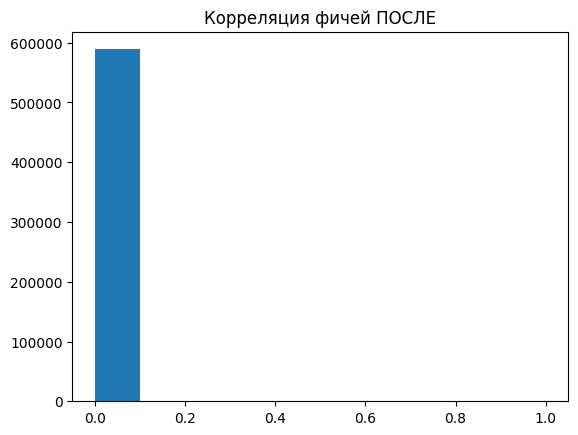

In [26]:
plt.title('Корреляция фичей ПОСЛЕ')
plt.hist((features @ features.T).detach().cpu().numpy().ravel());

In [27]:
torch.round(features @ features.T, decimals=3)

tensor([[1., -0., -0.,  ..., -0., -0., 0.],
        [-0., 1., 0.,  ..., -0., 0., -0.],
        [-0., 0., 1.,  ..., 0., 0., -0.],
        ...,
        [-0., -0., 0.,  ..., 1., 0., -0.],
        [-0., 0., 0.,  ..., 0., 1., -0.],
        [0., -0., -0.,  ..., -0., -0., 1.]], device='cuda:0',
       grad_fn=<RoundBackward1>)

In [28]:
assert torch.all(torch.isclose(torch.linalg.vector_norm(features, dim=1), torch.tensor(1.)))

**ВЫВОДЫ**

1) Если кол-во фичей не превосходит размерность гиперпространства, то можно выйти на ортогональный базис
2) При этом фичи будут кодироваться/декодироваться без ошибки. Т.е. мы итеративно приходим к тому, что получили через QR декомозицию
3) Поиск базиса напоминает автоэнкодер. Или это автоэнкодер напоминает поиск базиса

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

# Справочно

## Размер встраивания для GPT

| Model | Embedding Size (Dimensions) |
|---|---|
| GPT-1 | 768 |
| GPT-2 | 1,600 (for the 1.5B model) |
| GPT-3 | 12,288 |
| GPT-4 | ~16,000 (Estimated) |
| GPT-5 | Not officially released |


## Кол-во слоёв GPT

| Model [2, 3, 4, 5, 6, 7, 8, 9] | Layers (Transformer Blocks) | Parameters (Largest Version) |
|---|---|---|
| GPT-1 | 12 | 117 Million |
| GPT-2 | 48 | 1.5 Billion |
| GPT-3 | 96 | 175 Billion |
| GPT-4 | ~120–128* | 1.7–1.8 Trillion (Estimated) |
| GPT-5 | 48* | Unknown (Projected MoE architecture) |
